In [1]:
import pandas as pd
import os
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import json
from PIL import Image, ImageDraw
from lifelines import CoxPHFitter

data_path = '../data/'

In [2]:
from PIL import Image, ImageDraw
import numpy as np

def overlay_km_on_image(
    base_img: Image.Image,
    kmf,
    x_start_coord: tuple,  # (x0, y0) = origin where x-axis starts & y=0 baseline
    x_end_coord: tuple,    # (x1, y0) = end of x-axis baseline
    y_start_coord: tuple,  # (x0, y0) = same origin as above
    y_end_coord: tuple,    # (x0, y_top) = top of y-axis (S=1)
    *,
    t_min: float | None = None,   # override x-axis lower bound (defaults to min KM time or 0)
    t_max: float | None = None,   # override x-axis upper bound (defaults to max KM time)
    y_min: float = 0.0,           # lower bound for survival (usually 0)
    y_max: float = 1.0,           # upper bound for survival (usually 1)
    line_width: int = 4,
    color: str | tuple = "red",
):
    """
    Overlay a stepwise KM curve onto an existing image using pixel anchors for axes.
    Returns a new PIL.Image with the curve drawn on top.
    """

    # --- 1) Extract the stepwise KM curve (time, S) ---
    sf = kmf.survival_function_.copy()
    # lifelines column name is typically 'KM_estimate'
    if "KM_estimate" in sf.columns:
        s = sf["KM_estimate"].to_numpy()
    else:
        s = sf.iloc[:, 0].to_numpy()
    t = sf.index.to_numpy(dtype=float)

    # Ensure we start at (t_min, 1.0) like a KM step plot
    if t_min is None:
        # If earliest time > 0, prepend an initial step at t=0
        t0 = 0.0 if (len(t) == 0 or t[0] > 0) else t[0]
    else:
        t0 = float(t_min)

    if len(t) == 0 or t[0] > t0:
        t = np.insert(t, 0, t0)
        s = np.insert(s, 0, 1.0)

    if t_max is None:
        t_max = float(np.max(t) if len(t) else 1.0)
    else:
        t_max = float(t_max)

    # Clip any times outside [t0, t_max]
    mask = (t >= t0) & (t <= t_max)
    t = t[mask]
    s = s[mask]

    # Build step coordinates (stairs)
    # For times t0=t[0], t1, t2, ... with survival s0, s1, s2, ...
    # we draw horizontal then vertical segments to emulate KM.
    step_t = [t[0]]
    step_s = [s[0]]
    for i in range(1, len(t)):
        # horizontal segment at previous survival level up to t[i]
        step_t.append(t[i])
        step_s.append(step_s[-1])
        # vertical drop to new survival value at t[i]
        step_t.append(t[i])
        step_s.append(s[i])

    # Optionally extend a trailing horizontal to t_max if last time < t_max
    if step_t and step_t[-1] < t_max:
        step_t.append(t_max)
        step_s.append(step_s[-1])

    step_t = np.asarray(step_t, dtype=float)
    step_s = np.asarray(step_s, dtype=float)

    # --- 2) Build linear mappings from data -> pixel coords ---
    # Pixel anchors
    x0, y0 = x_start_coord
    x1, _y0_same = x_end_coord
    _x0_same, y_top = y_end_coord

    # Sanity: share the same origin for x_start and y_start
    # (no hard stop if not identical; we trust provided anchors)
    px_dx = float(x1 - x0)           # horizontal pixel span of x-axis
    px_dy = float(y0 - y_top)        # vertical pixel span (down is +, so y0>y_top)

    # Data spans
    data_tx = float(t_max - t0)
    data_sy = float(y_max - y_min)

    def x_to_px(t_val: np.ndarray | float) -> np.ndarray:
        return x0 + (np.asarray(t_val, dtype=float) - t0) / (data_tx if data_tx != 0 else 1.0) * px_dx

    def s_to_py(s_val: np.ndarray | float) -> np.ndarray:
        # s=y_max → y_top; s=y_min → y0
        return y0 - (np.asarray(s_val, dtype=float) - y_min) / (data_sy if data_sy != 0 else 1.0) * px_dy

    # Map all step points to pixels
    px = x_to_px(step_t)
    py = s_to_py(step_s)

    # --- 3) Draw on a copy of the base image ---
    img = base_img.copy()
    draw = ImageDraw.Draw(img)

    # Anti-aliased-ish by drawing short segments (Pillow doesn't do true AA lines)
    for i in range(1, len(px)):
        draw.line([(px[i-1], py[i-1]), (px[i], py[i])], fill=color, width=line_width)

    return img

from PIL import Image, ImageDraw, ImageFont

def overlay_km_on_image(
    base_img: Image.Image,
    kmf,
    x_start_coord: tuple,
    x_end_coord: tuple,
    y_start_coord: tuple,
    y_end_coord: tuple,
    *,
    t_min: float | None = None,
    t_max: float | None = None,
    y_min: float = 0.0,
    y_max: float = 1.0,
    line_width: int = 4,
    color: str | tuple = "red",
    legend_label: str | None = None,
    legend_pos: str = "top_right",  # "top_right", "top_left", "bottom_left", "bottom_right"
):
    """
    Overlay a Kaplan-Meier curve onto an existing image with optional legend.
    """

    # --- build stepwise curve (same as before) ---
    sf = kmf.survival_function_.copy()
    if "KM_estimate" in sf.columns:
        s = sf["KM_estimate"].to_numpy()
    else:
        s = sf.iloc[:, 0].to_numpy()
    t = sf.index.to_numpy(dtype=float)

    if t_min is None:
        t0 = 0.0 if (len(t) == 0 or t[0] > 0) else t[0]
    else:
        t0 = float(t_min)
    if len(t) == 0 or t[0] > t0:
        t = np.insert(t, 0, t0)
        s = np.insert(s, 0, 1.0)
    if t_max is None:
        t_max = float(np.max(t) if len(t) else 1.0)
    else:
        t_max = float(t_max)
    mask = (t >= t0) & (t <= t_max)
    t, s = t[mask], s[mask]

    step_t, step_s = [t[0]], [s[0]]
    for i in range(1, len(t)):
        step_t.append(t[i]); step_s.append(step_s[-1])
        step_t.append(t[i]); step_s.append(s[i])
    if step_t and step_t[-1] < t_max:
        step_t.append(t_max)
        step_s.append(step_s[-1])

    step_t, step_s = np.asarray(step_t), np.asarray(step_s)

    # --- axis mapping ---
    x0, y0 = x_start_coord
    x1, _ = x_end_coord
    _, y_top = y_end_coord
    px_dx, px_dy = float(x1 - x0), float(y0 - y_top)
    data_tx, data_sy = float(t_max - t0), float(y_max - y_min)

    def x_to_px(t_val): return x0 + (np.asarray(t_val) - t0) / (data_tx or 1.0) * px_dx
    def s_to_py(s_val): return y0 - (np.asarray(s_val) - y_min) / (data_sy or 1.0) * px_dy

    px, py = x_to_px(step_t), s_to_py(step_s)

    # --- draw ---
    img = base_img.copy()
    draw = ImageDraw.Draw(img)
    for i in range(1, len(px)):
        draw.line([(px[i-1], py[i-1]), (px[i], py[i])], fill=color, width=line_width)

    # --- legend ---
    if legend_label:
        # choose position
        W, H = img.size
        margin, box_h, box_w = 20, 40, 160
        if legend_pos == "top_left":
            xL, yL = margin, margin
        elif legend_pos == "bottom_left":
            xL, yL = margin, H - box_h - margin
        elif legend_pos == "bottom_right":
            xL, yL = W - box_w - margin, H - box_h - margin
        else:  # top_right
            xL, yL = W - box_w - margin, margin
        # draw background rectangle
        draw.rectangle([xL, yL, xL + box_w, yL + box_h], fill="white", outline="black")
        # draw line symbol
        line_y = yL + box_h // 2
        draw.line([(xL + 10, line_y), (xL + 60, line_y)], fill=color, width=4)
        # draw text
        try:
            font = ImageFont.load_default()
        except:
            font = None
        draw.text((xL + 70, yL + (box_h // 2 - 8)), legend_label, fill="black", font=font)

    return img

def overlay_km_on_image(
    base_img: Image.Image,
    kmf,
    x_start_coord: tuple,
    x_end_coord: tuple,
    y_start_coord: tuple,
    y_end_coord: tuple,
    *,
    t_min: float | None = None,
    t_max: float | None = None,
    y_min: float = 0.0,
    y_max: float = 1.0,
    line_width: int = 4,
    color: str | tuple = "red",
    legend_label: str | None = None,
    legend_pos: str = "top_right",  # "top_right", "top_left", "bottom_left", "bottom_right"
    # --- NEW optional kwargs for CI ---
    show_ci: bool = True,
    ci_alpha: int = 80,             # 0-255 transparency
    ci_color: str | tuple | None = None,
):
    """
    Overlay a Kaplan-Meier curve onto an existing image with optional legend
    and (optionally) a shaded confidence interval derived from kmf.confidence_interval_.
    """

    # --- build stepwise curve (same as before) ---
    sf = kmf.survival_function_.copy()
    if "KM_estimate" in sf.columns:
        s = sf["KM_estimate"].to_numpy()
    else:
        s = sf.iloc[:, 0].to_numpy()
    t = sf.index.to_numpy(dtype=float)

    if t_min is None:
        t0 = 0.0 if (len(t) == 0 or t[0] > 0) else t[0]
    else:
        t0 = float(t_min)
    if len(t) == 0 or t[0] > t0:
        t = np.insert(t, 0, t0)
        s = np.insert(s, 0, 1.0)
    if t_max is None:
        t_max = float(np.max(t) if len(t) else 1.0)
    else:
        t_max = float(t_max)
    mask = (t >= t0) & (t <= t_max)
    t, s = t[mask], s[mask]

    step_t, step_s = [t[0]], [s[0]]
    for i in range(1, len(t)):
        step_t.append(t[i]); step_s.append(step_s[-1])
        step_t.append(t[i]); step_s.append(s[i])
    if step_t and step_t[-1] < t_max:
        step_t.append(t_max)
        step_s.append(step_s[-1])
    step_t, step_s = np.asarray(step_t), np.asarray(step_s)

    # --- axis mapping ---
    x0, y0 = x_start_coord
    x1, _ = x_end_coord
    _, y_top = y_end_coord
    px_dx, px_dy = float(x1 - x0), float(y0 - y_top)
    data_tx, data_sy = float(t_max - t0), float(y_max - y_min)

    def x_to_px(t_val): return x0 + (np.asarray(t_val) - t0) / (data_tx or 1.0) * px_dx
    def s_to_py(s_val): return y0 - (np.asarray(s_val) - y_min) / (data_sy or 1.0) * px_dy

    px, py = x_to_px(step_t), s_to_py(step_s)

    # Prepare image (RGBA for alpha compositing)
    base_mode = base_img.mode
    if base_mode != "RGBA":
        img = base_img.convert("RGBA")
    else:
        img = base_img.copy()

    # --- confidence interval shading ---
    if show_ci:
        ci_df = getattr(kmf, "confidence_interval_", None)
        if ci_df is not None and len(ci_df) > 0:
            # Try to identify lower/upper columns robustly
            cols_lower = [c for c in ci_df.columns if "lower" in c.lower()]
            cols_upper = [c for c in ci_df.columns if "upper" in c.lower()]
            if len(cols_lower) == 0 or len(cols_upper) == 0:
                # Fallback: assume first two columns are [lower, upper] in name-sorted order
                sorted_cols = sorted(ci_df.columns.tolist())
                if len(sorted_cols) >= 2:
                    lower_col, upper_col = sorted_cols[0], sorted_cols[1]
                else:
                    lower_col = upper_col = None
            else:
                lower_col, upper_col = cols_lower[0], cols_upper[0]

            if lower_col is not None and upper_col is not None:
                ci_t = ci_df.index.to_numpy(dtype=float)

                # Restrict to [t0, t_max] and ensure we start at t0 with S=1.0 if needed
                # Build stepwise for lower/upper just like main curve
                def build_step(times, vals, default_at_t0=1.0):
                    tt, vv = times.copy(), vals.copy()
                    if len(tt) == 0 or tt[0] > t0:
                        tt = np.insert(tt, 0, t0)
                        vv = np.insert(vv, 0, default_at_t0)
                    # clip to window
                    m = (tt >= t0) & (tt <= t_max)
                    tt, vv = tt[m], vv[m]
                    # stepwise
                    st_t, st_v = [tt[0]], [vv[0]]
                    for i in range(1, len(tt)):
                        st_t.append(tt[i]); st_v.append(st_v[-1])
                        st_t.append(tt[i]); st_v.append(vv[i])
                    if st_t and st_t[-1] < t_max:
                        st_t.append(t_max); st_v.append(st_v[-1])
                    return np.asarray(st_t), np.asarray(st_v)

                lower_vals = ci_df[lower_col].to_numpy()
                upper_vals = ci_df[upper_col].to_numpy()
                stl_t, stl_v = build_step(ci_t, lower_vals, default_at_t0=1.0)
                stu_t, stu_v = build_step(ci_t, upper_vals, default_at_t0=1.0)

                # Map to pixels
                x_lower, y_lower = x_to_px(stl_t), s_to_py(stl_v)
                x_upper, y_upper = x_to_px(stu_t), s_to_py(stu_v)

                # Build polygon: go along upper, then back along lower reversed
                poly_x = np.concatenate([x_upper, x_lower[::-1]])
                poly_y = np.concatenate([y_upper, y_lower[::-1]])
                polygon = list(map(tuple, np.column_stack([poly_x, poly_y])))

                # Draw translucent fill on a separate overlay
                overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
                odraw = ImageDraw.Draw(overlay, "RGBA")
                fill_color = ci_color if ci_color is not None else color
                # Normalize named color to RGB if needed (ImageDraw handles both)
                if isinstance(fill_color, str):
                    # Let PIL parse the color name and then add alpha
                    # We approximate by drawing with (named_color, alpha) via RGBA tuple:
                    try:
                        # Convert via a 1x1 image trick to resolve the RGB
                        tmp = Image.new("RGBA", (1, 1), fill_color)
                        r, g, b, _ = tmp.getpixel((0, 0))
                        rgba = (r, g, b, int(ci_alpha))
                    except Exception:
                        rgba = (255, 0, 0, int(ci_alpha))
                else:
                    # Tuple provided; extend to RGBA with given alpha
                    if len(fill_color) == 3:
                        rgba = (fill_color[0], fill_color[1], fill_color[2], int(ci_alpha))
                    elif len(fill_color) == 4:
                        rgba = (fill_color[0], fill_color[1], fill_color[2], int(ci_alpha))
                    else:
                        rgba = (255, 0, 0, int(ci_alpha))

                odraw.polygon(polygon, fill=rgba)
                # Composite overlay onto the image
                img = Image.alpha_composite(img, overlay)

    # --- draw main KM line on top ---
    draw = ImageDraw.Draw(img)
    for i in range(1, len(px)):
        draw.line([(px[i-1], py[i-1]), (px[i], py[i])], fill=color, width=line_width)

    # --- legend ---
    if legend_label:
        # choose position
        W, H = img.size
        margin, box_h, box_w = 20, 40, 180
        if legend_pos == "top_left":
            xL, yL = margin, margin
        elif legend_pos == "bottom_left":
            xL, yL = margin, H - box_h - margin
        elif legend_pos == "bottom_right":
            xL, yL = W - box_w - margin, H - box_h - margin
        else:  # top_right
            xL, yL = W - box_w - margin, margin
        # draw background rectangle
        draw.rectangle([xL, yL, xL + box_w, yL + box_h], fill="white", outline="black")
        # draw line symbol
        line_y = yL + box_h // 2
        draw.line([(xL + 10, line_y), (xL + 60, line_y)], fill=color, width=4)

        # CI swatch (if shown)
        if show_ci:
            ci_fill_preview = ci_color if ci_color is not None else color
            # Resolve to RGBA as above
            if isinstance(ci_fill_preview, str):
                try:
                    tmp = Image.new("RGBA", (1, 1), ci_fill_preview)
                    r, g, b, _ = tmp.getpixel((0, 0))
                    rgba_ci = (r, g, b, int(ci_alpha))
                except Exception:
                    rgba_ci = (255, 0, 0, int(ci_alpha))
            else:
                if len(ci_fill_preview) == 3:
                    rgba_ci = (ci_fill_preview[0], ci_fill_preview[1], ci_fill_preview[2], int(ci_alpha))
                elif len(ci_fill_preview) == 4:
                    rgba_ci = (ci_fill_preview[0], ci_fill_preview[1], ci_fill_preview[2], int(ci_alpha))
                else:
                    rgba_ci = (255, 0, 0, int(ci_alpha))

            # Draw a small translucent rectangle as CI swatch
            ci_x0, ci_y0 = xL + 10, yL + 8
            ci_x1, ci_y1 = xL + 60, yL + 18
            ci_overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
            ImageDraw.Draw(ci_overlay, "RGBA").rectangle([ci_x0, ci_y0, ci_x1, ci_y1], fill=rgba_ci, outline=None)
            img = Image.alpha_composite(img, ci_overlay)

        # draw text
        try:
            font = ImageFont.load_default()
        except Exception:
            font = None
        draw = ImageDraw.Draw(img)  # refresh after alpha composite
        draw.text((xL + 70, yL + (box_h // 2 - 8)), legend_label, fill="black", font=font)

    # Convert back to original mode if needed
    if base_mode != "RGBA":
        img = img.convert(base_mode)

    return img

# LEO1010_PFS

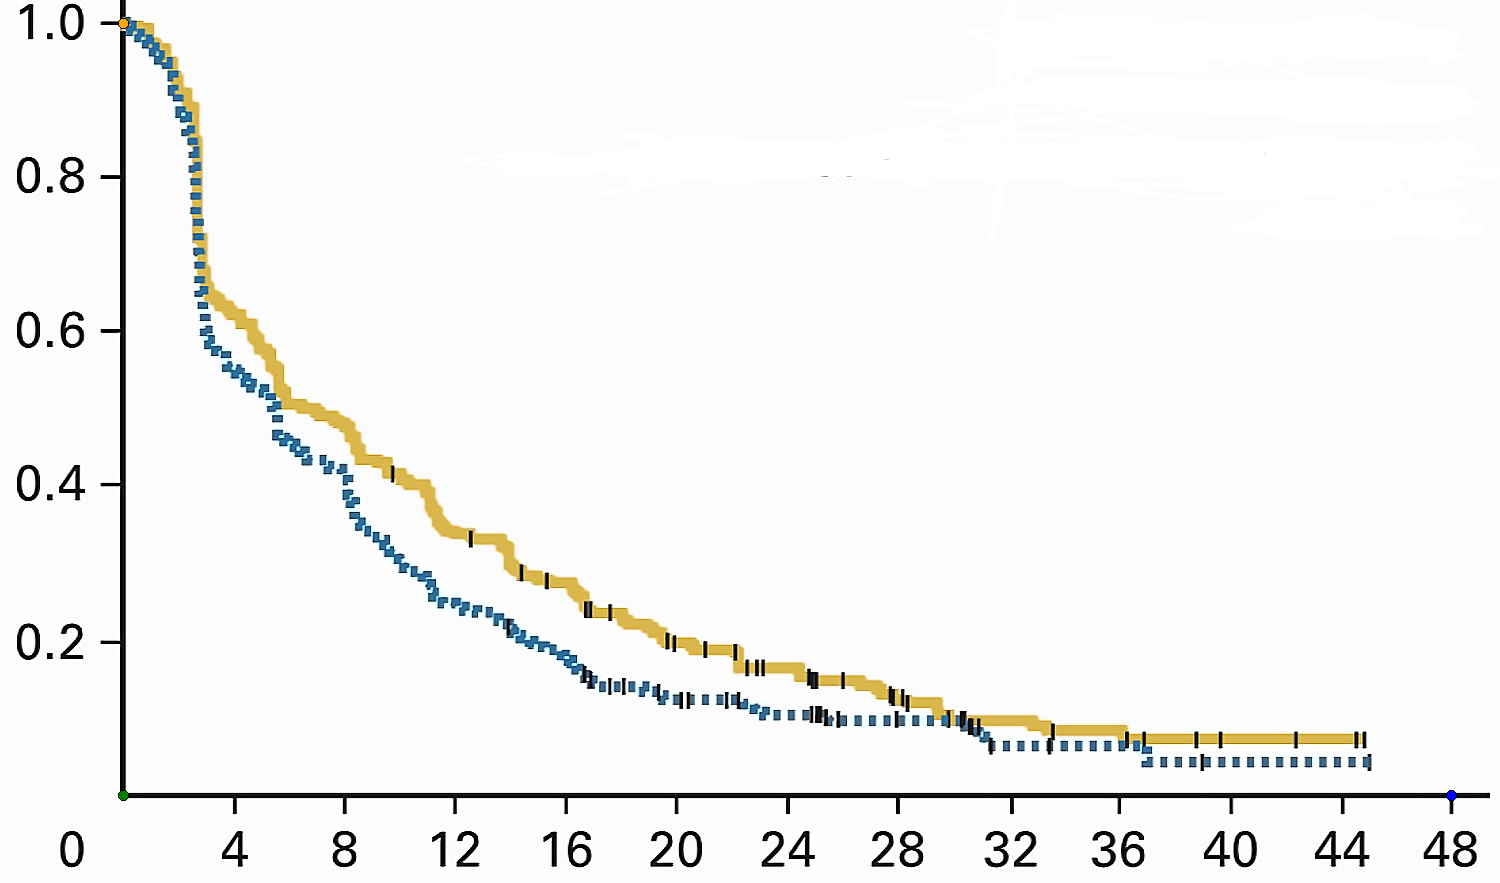

In [3]:
# Open image
image_file = data_path + "LEO1010_PFS/Plot/LEO1010_PFS_clean.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (123, 795)
x_end_coord   = (1451, 795)
y_start_coord = (123, 795)
y_end_coord   = (123, 23)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

## KM-GPT

Median survival time: 5.60 months
95% CI for S(t) at median: (3.78, 6.18) months
Median survival time: 6.81 months
95% CI for S(t) at median: (5.67, 8.65) months


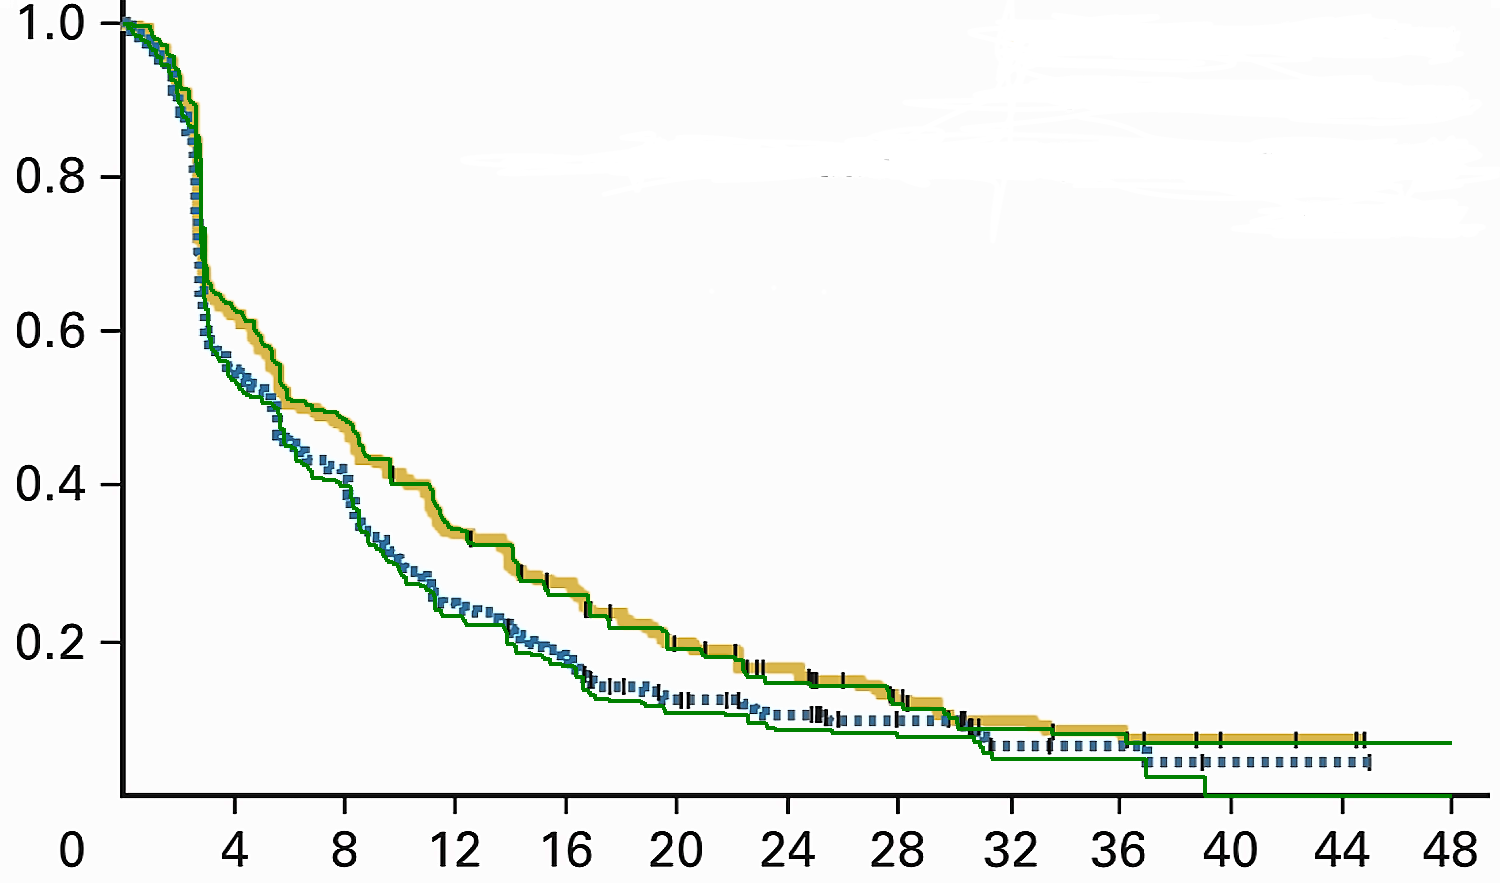

In [4]:
output = pd.read_csv(data_path + 'LEO1010_PFS/Reconstructed Data/KMGPT_IPD.csv')
df_500_auto = output[output['Group'] == 'Fulvestrant 500 mg']
df_250_auto = output[output['Group'] == 'Fulvestrant 250 mg']

# Open image
image_file = data_path + "LEO1010_PFS/Plot/LEO1010_PFS_clean.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (123, 795)
x_end_coord   = (1451, 795)
y_start_coord = (123, 795)
y_end_coord   = (123, 23)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df_250_auto['time'], event_observed=df_250_auto['status'])
# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=48,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

kmf = KaplanMeierFitter()
kmf.fit(df_500_auto['time'], event_observed=df_500_auto['status'])

# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")


overlaid = overlay_km_on_image(
    base_img=overlaid,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=48,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

overlaid

In [5]:
df_cox = pd.concat([df_500_auto, df_250_auto]).copy()

# 2. Encode the group variable
# CoxPH requires numerical inputs. We set Placebo as 0 (Reference) and Treatment as 1.
# This ensures the HR represents the effect of Treatment relative to Placebo.
df_cox['group_binary'] = df_cox['Group'].map({
    'Fulvestrant 500 mg': 1,      # Reference Group
    'Fulvestrant 250 mg': 0   # Treatment Group
})

# Ensure data types are correct
df_cox['time'] = df_cox['time'].astype(float)
df_cox['status'] = df_cox['status'].astype(int) # 1 if event occurred, 0 if censored

# 3. Fit the Cox Proportional Hazards Model
cph = CoxPHFitter()
# We subset only the necessary columns to avoid errors with unrelated data
cph.fit(df_cox[['time', 'status', 'group_binary']], duration_col='time', event_col='status')

# 4. Extract Results
# The model coefficients are log(HR). We take the exponent to get the HR.
hr = cph.hazard_ratios_['group_binary']
ci_lower = np.exp(cph.confidence_intervals_.loc['group_binary', '95% lower-bound'])
ci_upper = np.exp(cph.confidence_intervals_.loc['group_binary', '95% upper-bound'])
p_value = cph.summary.loc['group_binary', 'p']

print(f"Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)")
print(f"Hazard Ratio (HR): {hr:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f} - {ci_upper:.2f})")
print(f"P-value: {p_value:.4f}")

Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)
Hazard Ratio (HR): 0.76
95% Confidence Interval: (0.65 - 0.89)
P-value: 0.0007


## Manual

Median survival time: 5.58 months
95% CI for S(t) at median: (5.24, 6.56) months
Median survival time: 8.08 months
95% CI for S(t) at median: (5.78, 8.57) months


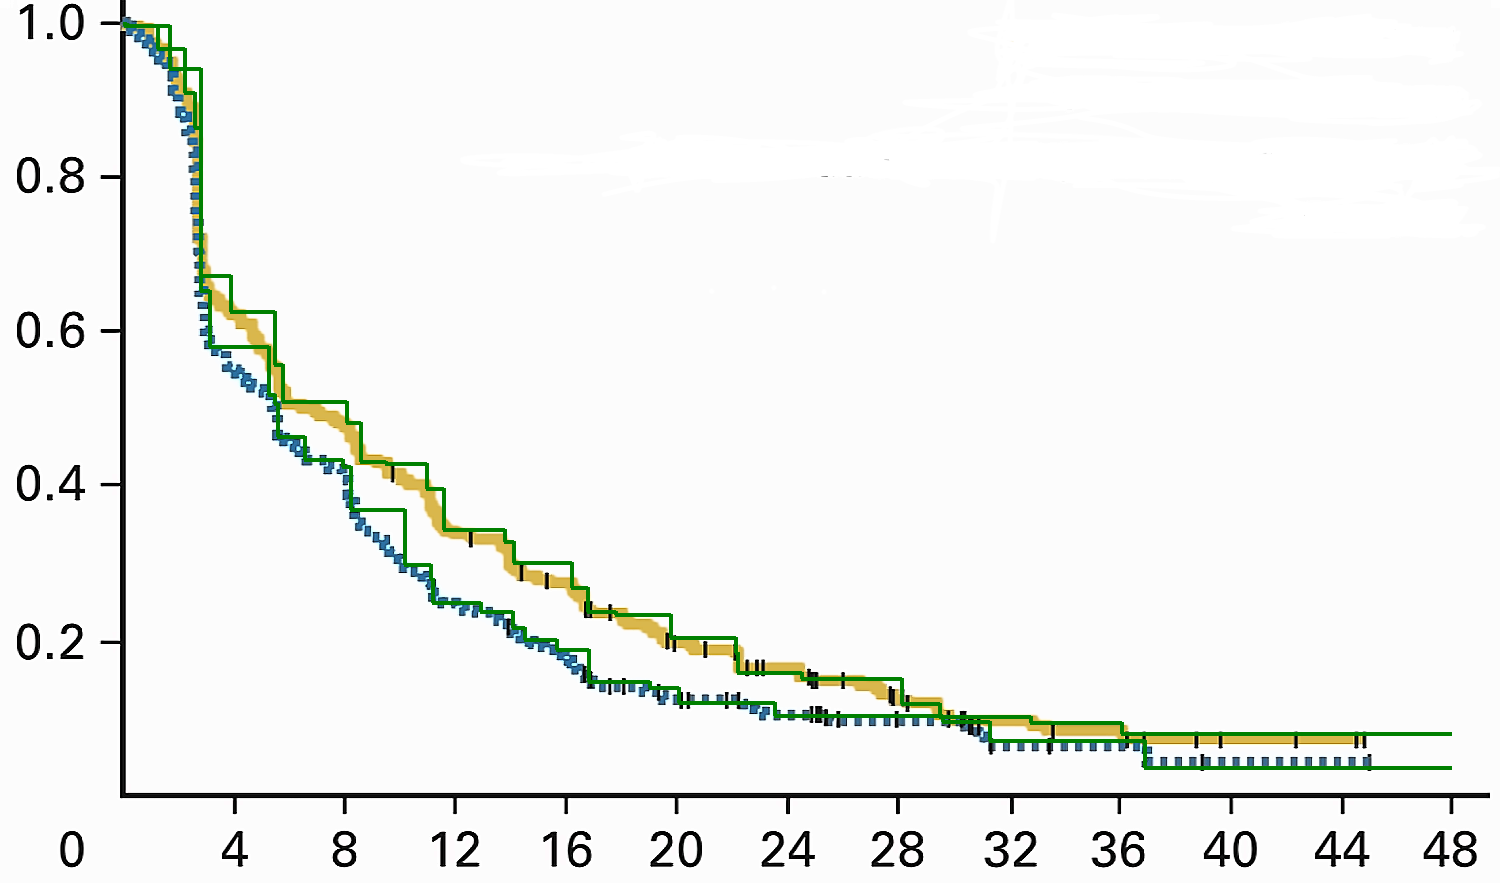

In [6]:
output = pd.read_csv(data_path + 'LEO1010_PFS/Reconstructed Data/Manual_IPD.csv')
df_500_auto = output[output['Group'] == 'Fulvestrant 500 mg']
df_250_auto = output[output['Group'] == 'Fulvestrant 250 mg']

# Open image
image_file = data_path + "LEO1010_PFS/Plot/LEO1010_PFS_clean.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (123, 795)
x_end_coord   = (1451, 795)
y_start_coord = (123, 795)
y_end_coord   = (123, 23)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df_250_auto['time'], event_observed=df_250_auto['status'])
# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=48,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

kmf = KaplanMeierFitter()
kmf.fit(df_500_auto['time'], event_observed=df_500_auto['status'])
# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=overlaid,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=48,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

overlaid

In [7]:
df_cox = pd.concat([df_500_auto, df_250_auto]).copy()

# 2. Encode the group variable
# CoxPH requires numerical inputs. We set Placebo as 0 (Reference) and Treatment as 1.
# This ensures the HR represents the effect of Treatment relative to Placebo.
df_cox['group_binary'] = df_cox['Group'].map({
    'Fulvestrant 500 mg': 1,      # Reference Group
    'Fulvestrant 250 mg': 0   # Treatment Group
})

# Ensure data types are correct
df_cox['time'] = df_cox['time'].astype(float)
df_cox['status'] = df_cox['status'].astype(int) # 1 if event occurred, 0 if censored

# 3. Fit the Cox Proportional Hazards Model
cph = CoxPHFitter()
# We subset only the necessary columns to avoid errors with unrelated data
cph.fit(df_cox[['time', 'status', 'group_binary']], duration_col='time', event_col='status')

# 4. Extract Results
# The model coefficients are log(HR). We take the exponent to get the HR.
hr = cph.hazard_ratios_['group_binary']
ci_lower = np.exp(cph.confidence_intervals_.loc['group_binary', '95% lower-bound'])
ci_upper = np.exp(cph.confidence_intervals_.loc['group_binary', '95% upper-bound'])
p_value = cph.summary.loc['group_binary', 'p']

print(f"Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)")
print(f"Hazard Ratio (HR): {hr:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f} - {ci_upper:.2f})")
print(f"P-value: {p_value:.4f}")

Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)
Hazard Ratio (HR): 0.79
95% Confidence Interval: (0.67 - 0.93)
P-value: 0.0043


# LANG0213_PFS

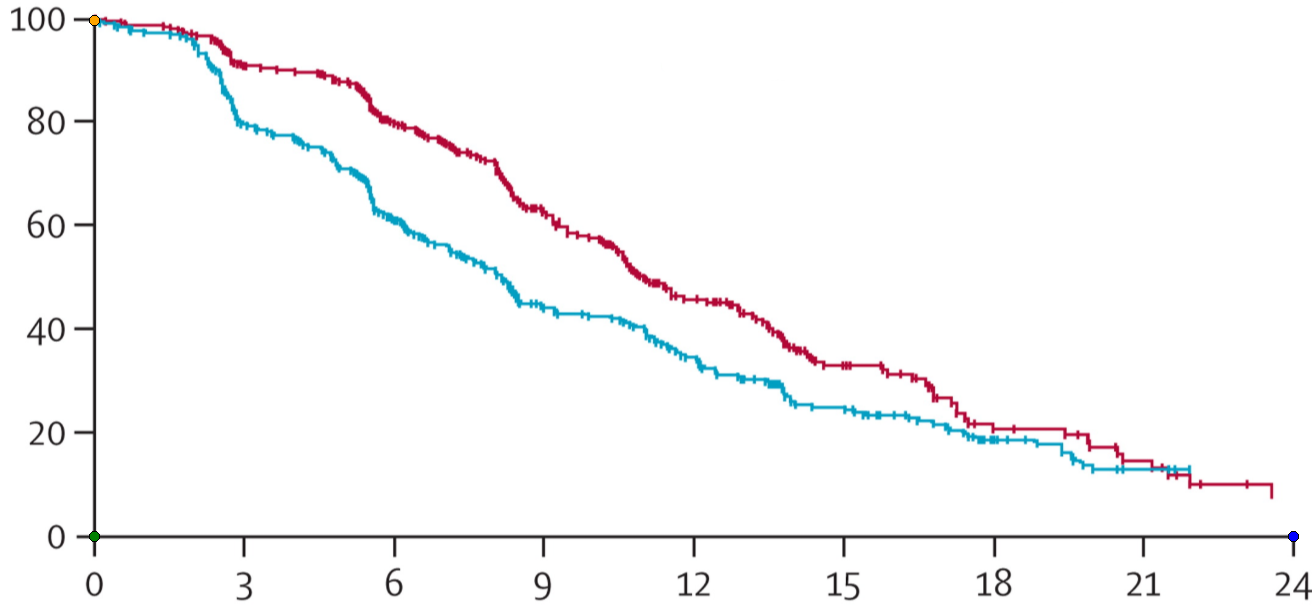

In [8]:
# Open image
fig_name = "LANG0213_PFS"
image_file = data_path + f"{fig_name}/{fig_name}_cleaned.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (94, 536)
x_end_coord   = (1293, 536)
y_start_coord = (94, 536)
y_end_coord   = (94, 20)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

## KM-GPT

Median survival time: 7.96 months
95% CI for S(t) at median: (6.60, 8.46) months
Median survival time: 10.74 months
95% CI for S(t) at median: (9.82, 12.18) months


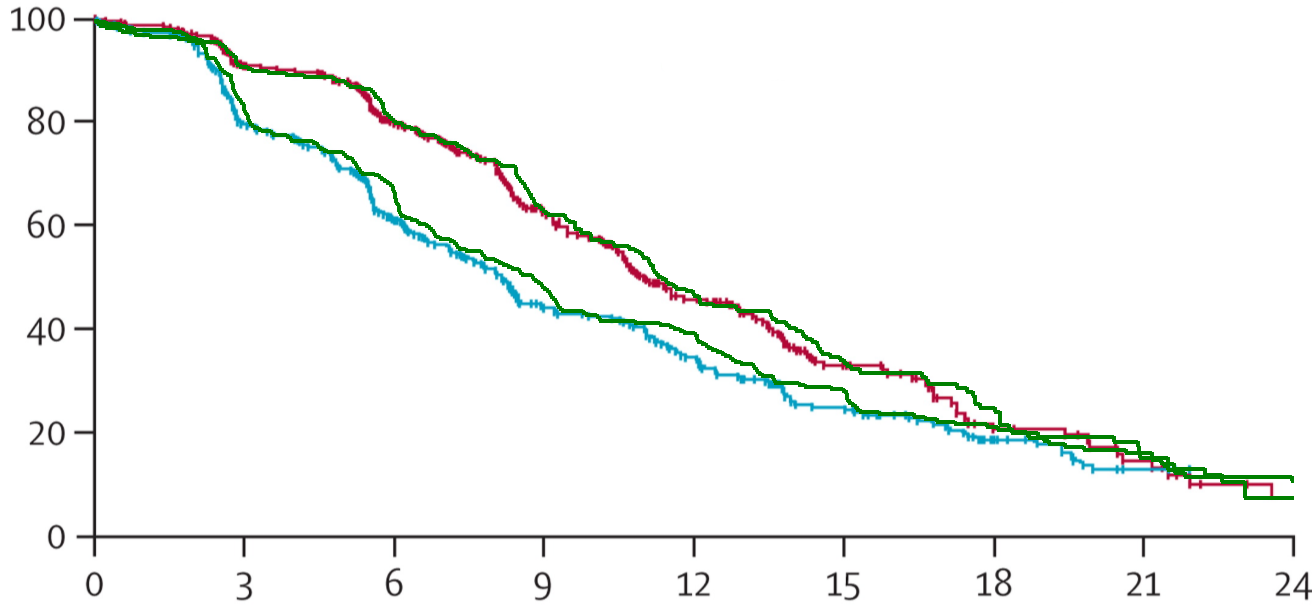

In [9]:
fig_name = "LANG0213_PFS"

output = pd.read_csv(data_path + f'{fig_name}/Reconstructed Data/KMGPT_IPD.csv')
df_500_auto = output[output['Group'] == 'Bevacizumab plus paclitaxel']
df_250_auto = output[output['Group'] == 'Bevacizumab plus capecitabine']

# Open image
image_file = data_path + f"{fig_name}/{fig_name}_cleaned.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (94, 536)
x_end_coord   = (1293, 536)
y_start_coord = (94, 536)
y_end_coord   = (94, 20)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df_250_auto['time'].astype(float), event_observed=df_250_auto['status'].astype(bool))

# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=None,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

kmf = KaplanMeierFitter()
kmf.fit(df_500_auto['time'], event_observed=df_500_auto['status'])

# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=overlaid,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=None,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

overlaid

In [10]:
df_cox = pd.concat([df_500_auto, df_250_auto]).copy()

# 2. Encode the group variable
# CoxPH requires numerical inputs. We set Placebo as 0 (Reference) and Treatment as 1.
# This ensures the HR represents the effect of Treatment relative to Placebo.
df_cox['group_binary'] = df_cox['Group'].map({
    'Bevacizumab plus paclitaxel': 0,      # Reference Group
    'Bevacizumab plus capecitabine': 1   # Treatment Group
})

# Ensure data types are correct
df_cox['time'] = df_cox['time'].astype(float)
df_cox['status'] = df_cox['status'].astype(int) # 1 if event occurred, 0 if censored

# 3. Fit the Cox Proportional Hazards Model
cph = CoxPHFitter()
# We subset only the necessary columns to avoid errors with unrelated data
cph.fit(df_cox[['time', 'status', 'group_binary']], duration_col='time', event_col='status')

# 4. Extract Results
# The model coefficients are log(HR). We take the exponent to get the HR.
hr = cph.hazard_ratios_['group_binary']
ci_lower = np.exp(cph.confidence_intervals_.loc['group_binary', '95% lower-bound'])
ci_upper = np.exp(cph.confidence_intervals_.loc['group_binary', '95% upper-bound'])
p_value = cph.summary.loc['group_binary', 'p']

print(f"Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)")
print(f"Hazard Ratio (HR): {hr:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f} - {ci_upper:.2f})")
print(f"P-value: {p_value:.4f}")

Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)
Hazard Ratio (HR): 1.34
95% Confidence Interval: (1.10 - 1.63)
P-value: 0.0031


## Manual

Median survival time: 8.55 months
95% CI for S(t) at median: (7.52, 9.35) months
Median survival time: 11.14 months
95% CI for S(t) at median: (10.80, 13.57) months


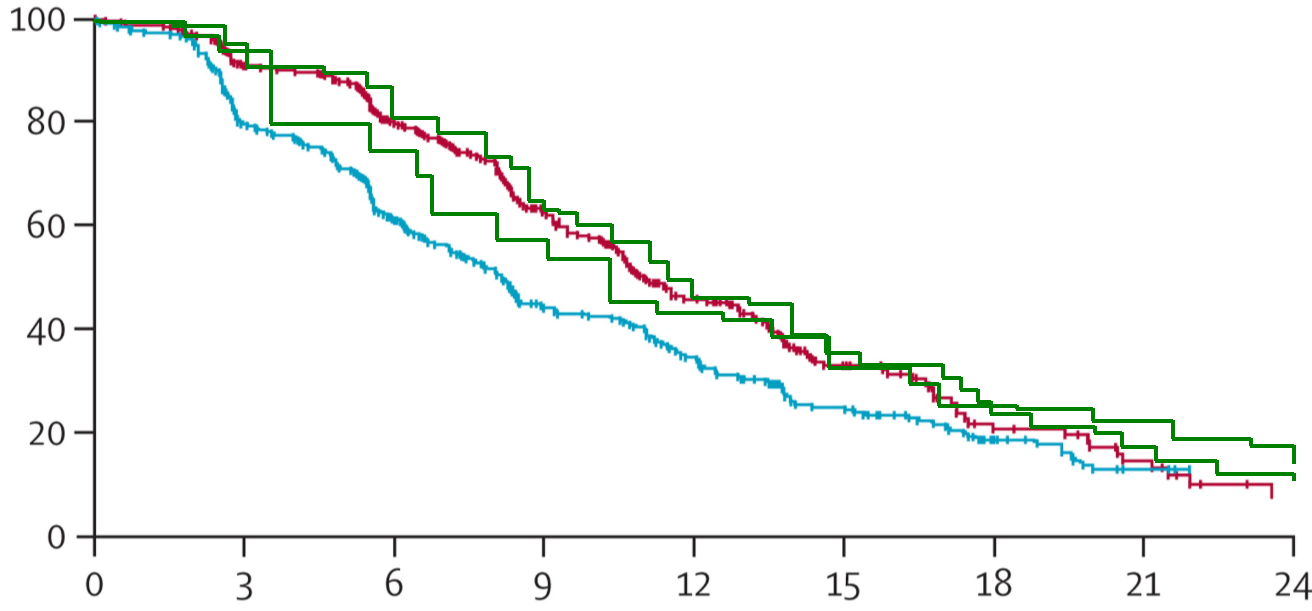

In [11]:
fig_name = "LANG0213_PFS"

output = pd.read_csv(data_path + f'{fig_name}/Reconstructed Data/Manual_IPD.csv')
df_500_auto = output[output['Group'] == 'Bevacizumab plus paclitaxel']
df_250_auto = output[output['Group'] == 'Bevacizumab plus capecitabine']

# Open image
image_file = data_path + f"{fig_name}/{fig_name}_cleaned.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (94, 536)
x_end_coord   = (1293, 536)
y_start_coord = (94, 536)
y_end_coord   = (94, 20)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df_250_auto['time'].astype(float), event_observed=df_250_auto['status'].astype(bool))
# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")
overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=None,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

kmf = KaplanMeierFitter()
kmf.fit(df_500_auto['time'], event_observed=df_500_auto['status'])
# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")
overlaid = overlay_km_on_image(
    base_img=overlaid,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=None,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

overlaid

In [12]:
df_cox = pd.concat([df_500_auto, df_250_auto]).copy()

# 2. Encode the group variable
# CoxPH requires numerical inputs. We set Placebo as 0 (Reference) and Treatment as 1.
# This ensures the HR represents the effect of Treatment relative to Placebo.
df_cox['group_binary'] = df_cox['Group'].map({
    'Bevacizumab plus paclitaxel': 0,      # Reference Group
    'Bevacizumab plus capecitabine': 1   # Treatment Group
})

# Ensure data types are correct
df_cox['time'] = df_cox['time'].astype(float)
df_cox['status'] = df_cox['status'].astype(int) # 1 if event occurred, 0 if censored

# 3. Fit the Cox Proportional Hazards Model
cph = CoxPHFitter()
# We subset only the necessary columns to avoid errors with unrelated data
cph.fit(df_cox[['time', 'status', 'group_binary']], duration_col='time', event_col='status')

# 4. Extract Results
# The model coefficients are log(HR). We take the exponent to get the HR.
hr = cph.hazard_ratios_['group_binary']
ci_lower = np.exp(cph.confidence_intervals_.loc['group_binary', '95% lower-bound'])
ci_upper = np.exp(cph.confidence_intervals_.loc['group_binary', '95% upper-bound'])
p_value = cph.summary.loc['group_binary', 'p']

print(f"Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)")
print(f"Hazard Ratio (HR): {hr:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f} - {ci_upper:.2f})")
print(f"P-value: {p_value:.4f}")

Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)
Hazard Ratio (HR): 1.49
95% Confidence Interval: (1.20 - 1.86)
P-value: 0.0003


# ZAMAN0715_OS

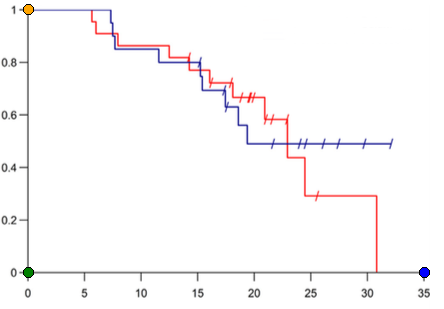

In [13]:
# Open image
fig_name = "ZAMAN0715_OS"
image_file = data_path + f"{fig_name}/{fig_name}_clean.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (28, 272)
x_end_coord   = (424, 272)
y_start_coord = (28, 272)
y_end_coord   = (28, 9)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

# Draw circles on the image
for name, (coord, color) in points.items():
    x, y = coord
    r = 5
    draw.ellipse((x-r, y-r, x+r, y+r), fill=color, outline="black")

original_image

## KM-GPT

Median survival time: 22.91 months
95% CI for S(t) at median: (16.21, 31.03) months
Median survival time: 19.51 months
95% CI for S(t) at median: (15.36, nan) months


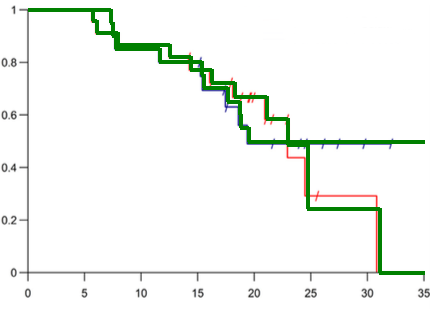

In [14]:
output = pd.read_csv(data_path + f'{fig_name}/Reconstructed Data/KMGPT_IPD.csv')
df_500_auto = output[output['Group'] == 'Fulvestrant + Placebo']
df_250_auto = output[output['Group'] == 'Fulvestrant + Selumetinib']

# Open image
image_file = data_path + f"{fig_name}/{fig_name}_clean.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (28, 272)
x_end_coord   = (424, 272)
y_start_coord = (28, 272)
y_end_coord   = (28, 9)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df_250_auto['time'].astype(float), event_observed=df_250_auto['status'].astype(bool))

# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=35,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

kmf = KaplanMeierFitter()
kmf.fit(df_500_auto['time'], event_observed=df_500_auto['status'])

# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=overlaid,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=35,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

overlaid

In [15]:
df_cox = pd.concat([df_500_auto, df_250_auto]).copy()

# 2. Encode the group variable
# CoxPH requires numerical inputs. We set Placebo as 0 (Reference) and Treatment as 1.
# This ensures the HR represents the effect of Treatment relative to Placebo.
df_cox['group_binary'] = df_cox['Group'].map({
    'Fulvestrant + Placebo': 0,      # Reference Group
    'Fulvestrant + Selumetinib': 1   # Treatment Group
})

# Ensure data types are correct
df_cox['time'] = df_cox['time'].astype(float)
df_cox['status'] = df_cox['status'].astype(int) # 1 if event occurred, 0 if censored

# 3. Fit the Cox Proportional Hazards Model
cph = CoxPHFitter()
# We subset only the necessary columns to avoid errors with unrelated data
cph.fit(df_cox[['time', 'status', 'group_binary']], duration_col='time', event_col='status')

# 4. Extract Results
# The model coefficients are log(HR). We take the exponent to get the HR.
hr = cph.hazard_ratios_['group_binary']
ci_lower = np.exp(cph.confidence_intervals_.loc['group_binary', '95% lower-bound'])
ci_upper = np.exp(cph.confidence_intervals_.loc['group_binary', '95% upper-bound'])
p_value = cph.summary.loc['group_binary', 'p']

print(f"Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)")
print(f"Hazard Ratio (HR): {hr:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f} - {ci_upper:.2f})")
print(f"P-value: {p_value:.4f}")

Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)
Hazard Ratio (HR): 1.37
95% Confidence Interval: (0.58 - 3.24)
P-value: 0.4686


## Manual

Median survival time: 23.24 months
95% CI for S(t) at median: (16.93, nan) months
Median survival time: inf months
95% CI for S(t) at median: (16.22, nan) months


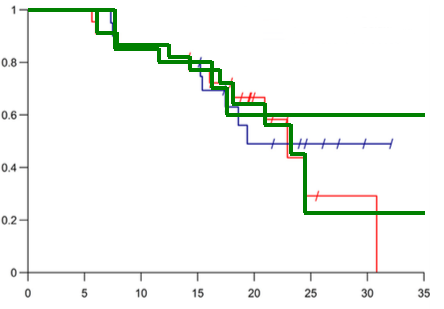

In [16]:
output = pd.read_csv(data_path + f'{fig_name}/Reconstructed Data/Manual_IPD.csv')
df_500_auto = output[output['Group'] == 'Fulvestrant + Placebo']
df_250_auto = output[output['Group'] == 'Fulvestrant + Selumetinib']

# Open image
image_file = data_path + f"{fig_name}/{fig_name}_clean.png"
original_image = Image.open(image_file).convert("RGB")
draw = ImageDraw.Draw(original_image)

# Coordinates
x_start_coord = (28, 272)
x_end_coord   = (424, 272)
y_start_coord = (28, 272)
y_end_coord   = (28, 9)

# Define all points and colors
points = {
    "x_start": (x_start_coord, "red"),
    "x_end": (x_end_coord, "blue"),
    "y_start": (y_start_coord, "green"),
    "y_end": (y_end_coord, "orange"),
}

from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()
kmf.fit(df_250_auto['time'].astype(float), event_observed=df_250_auto['status'].astype(bool))

# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=original_image,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=35,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

kmf = KaplanMeierFitter()
kmf.fit(df_500_auto['time'], event_observed=df_500_auto['status'])

# Point estimate of median
median_ = kmf.median_survival_time_

# Extract CI for the survival function
ci_df = kmf.confidence_interval_survival_function_

# Function to find time when curve crosses 0.5
def time_at_prob(curve, prob=0.5):
    below = curve[curve <= prob]
    if below.empty:
        return np.nan
    return below.index[0]

# Lower and upper CI bounds
median_lower = time_at_prob(ci_df['KM_estimate_lower_0.95'])  # upper CI curve (lower survival)
median_upper = time_at_prob(ci_df['KM_estimate_upper_0.95'])  # lower CI curve (upper survival)

print(f"Median survival time: {median_:.2f} months")
print(f"95% CI for S(t) at median: ({median_lower:.2f}, {median_upper:.2f}) months")

overlaid = overlay_km_on_image(
    base_img=overlaid,
    kmf=kmf,
    x_start_coord=x_start_coord,
    x_end_coord=x_end_coord,
    y_start_coord=y_start_coord,
    y_end_coord=y_end_coord,
    t_min=0.0,         # optional; set if you want x-axis to start at 0 exactly
    t_max=35,        # optional; defaults to max observed time
    y_min=0.0,
    y_max=1.0,
    line_width=4,
    color="green",
    show_ci=False
)

overlaid

In [17]:
df_cox = pd.concat([df_500_auto, df_250_auto]).copy()

# 2. Encode the group variable
# CoxPH requires numerical inputs. We set Placebo as 0 (Reference) and Treatment as 1.
# This ensures the HR represents the effect of Treatment relative to Placebo.
df_cox['group_binary'] = df_cox['Group'].map({
    'Fulvestrant + Placebo': 0,      # Reference Group
    'Fulvestrant + Selumetinib': 1   # Treatment Group
})

# Ensure data types are correct
df_cox['time'] = df_cox['time'].astype(float)
df_cox['status'] = df_cox['status'].astype(int) # 1 if event occurred, 0 if censored

# 3. Fit the Cox Proportional Hazards Model
cph = CoxPHFitter()
# We subset only the necessary columns to avoid errors with unrelated data
cph.fit(df_cox[['time', 'status', 'group_binary']], duration_col='time', event_col='status')

# 4. Extract Results
# The model coefficients are log(HR). We take the exponent to get the HR.
hr = cph.hazard_ratios_['group_binary']
ci_lower = np.exp(cph.confidence_intervals_.loc['group_binary', '95% lower-bound'])
ci_upper = np.exp(cph.confidence_intervals_.loc['group_binary', '95% upper-bound'])
p_value = cph.summary.loc['group_binary', 'p']

print(f"Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)")
print(f"Hazard Ratio (HR): {hr:.2f}")
print(f"95% Confidence Interval: ({ci_lower:.2f} - {ci_upper:.2f})")
print(f"P-value: {p_value:.4f}")

Comparison: Fulvestrant + Selumetinib (1) vs. Fulvestrant + Placebo (0)
Hazard Ratio (HR): 0.99
95% Confidence Interval: (0.37 - 2.68)
P-value: 0.9887
